# Boosted Decision Tree Skeleton


In this cell, split the dataset into _train_ and _test_ samples, using sci-kit learn `train_test_split()`.


In [ ]:
import sys
sys.path.append("/users/xn22103/atmospherics-tools/fast-osc-feedback/")

import polars as pl
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]

Enu_e_had= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_e_calo = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
Enu_mu_had= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
PDG = "rec/mc/mc.nu/mc.nu.pdg"

caf_data = caf_tree.arrays([Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, PDG])

caf_df = pl.from_pandas(ak.to_dataframe(caf_data, how = "outer"))
caf_df.columns = ["Enu_e_had","Enu_e_calo","Enu_mu_had","Enu_mu_range","PDG"]

reco_pfp_tree = uproot.open("reco_pfp_info.root")["reco_pfp_tree"]
reco_pfp_df = pl.from_pandas(reco_pfp_tree.arrays(library="pd"))

data = pl.concat([caf_df, reco_pfp_df], how="horizontal")

data = data.with_row_index("event_index")

data = data.filter(pl.col("reco_ok") == True)


data = data.with_columns(
	((pl.col("Enu_e_had") / pl.col("Enu_e_calo"))).alias("inelasticity_e"),
	((pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))).alias("inelasticity_mu"),
	(pl.col("PDG") < 0).cast(pl.Int64).alias("label"))



data = data.to_pandas()
data = data.dropna()
data

,event_index,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,inelasticity_e,inelasticity_mu,label
0,0,1.237640e+01,28.432413,28.015844,28.529816,-12,True,10,5,4,11.487990,4,1,4.352918e-01,0.985349,1
1,1,9.994991e-02,0.208079,0.099950,0.322256,-12,True,2,1,0,0.110940,1,0,4.803471e-01,0.480347,1
2,2,3.063447e-01,1.156426,0.306345,1.201710,-14,True,4,3,0,0.064570,2,1,2.649064e-01,0.264906,1
3,4,8.884442e-02,0.502835,0.088844,0.593700,14,True,3,2,0,0.002420,1,1,1.766871e-01,0.176687,0
4,5,3.318707e-03,0.299485,0.003319,0.299201,16,True,2,1,0,0.003319,1,0,1.108138e-02,0.011081,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2651022,2884698,-8.104407e-17,0.156685,0.000000,0.256748,14,True,2,1,0,0.000000,1,0,-5.172407e-16,0.000000,0
2651023,2884699,2.552473e-03,0.169946,0.002552,0.260973,14,True,2,1,0,0.005397,1,0,1.501929e-02,0.015019,0
2651024,2884700,1.402719e-02,0.124140,0.014027,0.207403,14,True,3,1,1,0.012165,1,0,1.129947e-01,0.112995,0
2651025,2884701,5.641751e-02,1.383207,1.343197,1.471067,12,True,3,1,1,0.102556,0,1,4.078746e-02,0.971074,0


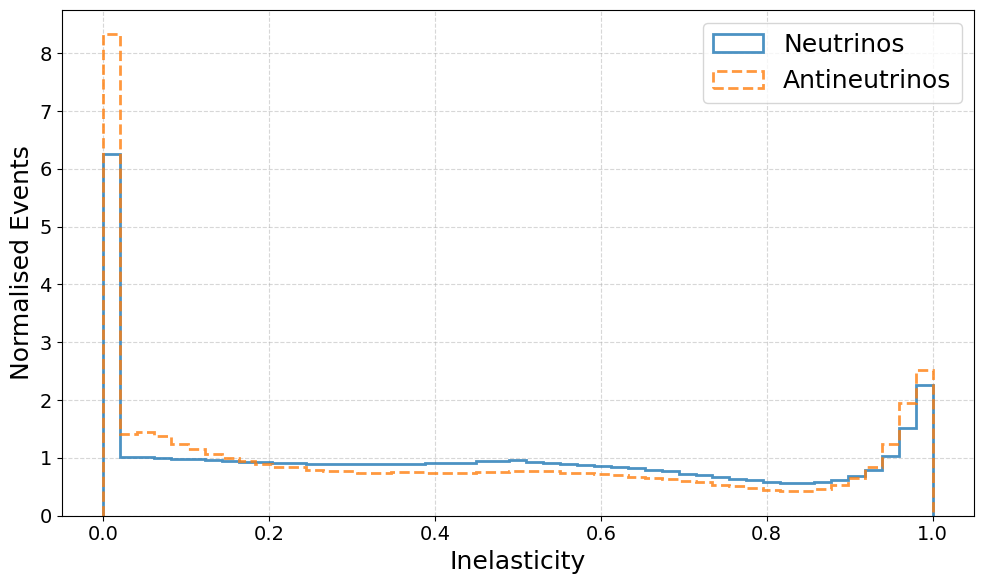

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

neutrinos = data[data['label'] == 0]
antineutrinos = data[data['label'] == 1]

def set_plot_style():
	plt.rcParams.update({
		"font.size": 12,
		"axes.labelsize": 18,
		"xtick.labelsize": 14,
		"ytick.labelsize": 14,
		"legend.fontsize": 18,
		"lines.linewidth": 1.5
	})
	
set_plot_style()

all_neutrinos = pd.concat([neutrinos['inelasticity_e'], neutrinos['inelasticity_mu']])
all_antineutrinos = pd.concat([antineutrinos['inelasticity_e'], antineutrinos['inelasticity_mu']])

fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(0, 1, 50)

ax.hist(all_neutrinos, bins=bins, alpha=0.8, density=True, histtype='step', linewidth=2, label='Neutrinos')
ax.hist(all_antineutrinos, bins=bins, alpha=0.8, density=True, histtype='step', linewidth=2, linestyle='--', label='Antineutrinos')


ax.grid(True, alpha=0.5, linestyle='--')
ax.legend()
ax.set_xlabel('Inelasticity')
ax.set_ylabel('Normalised Events')

plt.tight_layout()
fig.savefig("inelasticity_distributions_combined.pdf", bbox_inches='tight')
plt.show()

In [37]:
# code to set only the inelasticity of the correct neutrino type to non zero for each event

import numpy as np

data["inelasticity"] = np.select([data["PDG"].abs() == 14,data["PDG"].abs() == 12,],[data["inelasticity_mu"],data["inelasticity_e"],],default=np.nan)
nu_mask = data['label'] == 0

data = data.drop(columns=["inelasticity_e", "inelasticity_mu"])

data= data[data["PDG"].abs() != 16]

print(len(data[data["inelasticity"] >= 0.99]))
print(len(data[data["inelasticity"] != 0]))

data = data[data["inelasticity"] != 0]

data


KeyError: 'inelasticity_mu'

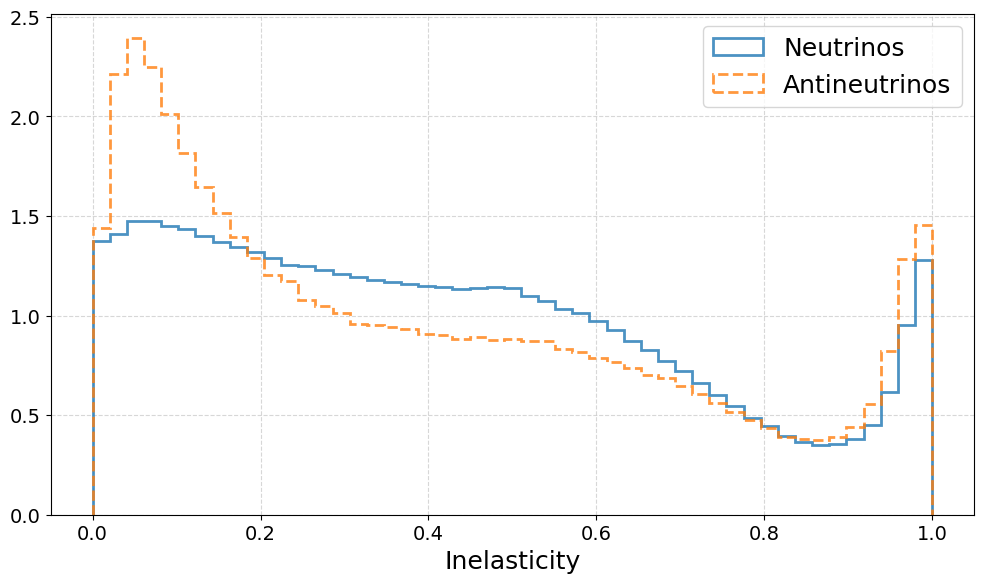

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

neutrinos = data[data['label'] == 0]
antineutrinos = data[data['label'] == 1]

def set_plot_style():
	plt.rcParams.update({
		"font.size": 12,
		"axes.labelsize": 18,
		"xtick.labelsize": 14,
		"ytick.labelsize": 14,
		"legend.fontsize": 18,
		"lines.linewidth": 1.5
	})
	
set_plot_style()

all_neutrinos = pd.concat([neutrinos['inelasticity']])
all_antineutrinos = pd.concat([antineutrinos['inelasticity']])

fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(0, 1, 50)

ax.hist(all_neutrinos, bins=bins, alpha=0.8, density=True, histtype='step', linewidth=2, label='Neutrinos')
ax.hist(all_antineutrinos, bins=bins, alpha=0.8, density=True, histtype='step', linewidth=2, linestyle='--', label='Antineutrinos')


ax.grid(True, alpha=0.5, linestyle='--')
ax.legend()
ax.set_xlabel('Inelasticity')

plt.tight_layout()
fig.savefig("inelasticity_distributions_combined_cut.pdf", bbox_inches='tight')
plt.show()

In [5]:
import pandas as pd

consistency = pd.crosstab(data['PDG'] < 0, data['label'])
consistency.index = ['PDG > 0 (Nu)', 'PDG < 0 (Anti-Nu)']
consistency.columns = ['Label 0', 'Label 1']
print(consistency)

                   Label 0  Label 1
PDG > 0 (Nu)       1593306        0
PDG < 0 (Anti-Nu)        0   501033


In [6]:
electron_mask = data['PDG'].abs() == 12
muon_mask = data['PDG'].abs() == 14
tau_mask = data['PDG'].abs() == 16


electron_data = data[electron_mask]
muon_data = data[muon_mask] 
tau_data = data[tau_mask]
data_pfp_1 = data[data["n_reco_pfps"] > 1]
# data_E_10gev = data_pfp_1[data_pfp_1["E"] > 10]

In [7]:
data_type = data_pfp_1


feature_columns = ['inelasticity', 'n_reco_pfps', 'n_reco_tracks', 'n_reco_showers', 'single_hits_energy', 'n_reco_muons_pions', 'n_reco_protons']
data_type = data_type.dropna()

# for col in [
# 	"single_hits_energy",
# 	"n_reco_pfps",
# 	"n_reco_tracks",
# 	"n_reco_showers",
# 	"n_reco_protons",
# ]:
# 	data[col] = np.log1p(data[col])


X_data = data_type[feature_columns].values


y_data = data_type['label'].values

data_type[feature_columns]

,inelasticity,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons
0,0.435292,10,5,4,11.487990,4,1
1,0.480347,2,1,0,0.110940,1,0
2,0.254924,4,3,0,0.064570,2,1
3,0.149645,3,2,0,0.002420,1,1
6,0.223056,2,1,0,0.078158,0,1
...,...,...,...,...,...,...,...
2651020,0.399207,8,1,4,0.329317,0,1
2651021,0.492007,4,2,1,0.164924,1,1
2651023,0.009781,2,1,0,0.005397,1,0
2651024,0.067633,3,1,1,0.012165,1,0


In [8]:
print(np.unique(y_data, return_counts=True))


(array([0, 1]), array([1593306,  501033]))


In [9]:
from sklearn.model_selection import train_test_split

# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.33, random_state=42)

Train the BDT using the `GradientBoostingClassifier` from sci-kit learn.  Note that `HistGradientBoostingClassifier` is also available, and should be more computationally efficient on large samples (>10k).

In [10]:
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.ensemble import HistGradientBoostingClassifier
# clf = HistGradientBoostingClassifier(
# 	learning_rate=0.05,
# 	max_depth=None,
#     max_leaf_nodes=31,
# 	min_samples_leaf=50,
# 	max_iter=2000,
# 	class_weight="balanced",
# 	early_stopping=True,
# 	# validation_fraction=0.2,
# 	# n_iter_no_change=30,
# 	random_state=0,
# ).fit(X_train, y_train)

In [11]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier(
	learning_rate=0.01,
    l2_regularization=0.01,
	max_depth=None,
    max_leaf_nodes=60,
	min_samples_leaf=5,
	max_iter=2000,
	class_weight="balanced",
	early_stopping=True,
	# validation_fraction=0.2,
	# n_iter_no_change=30,
	random_state=0,
).fit(X_train, y_train)

Now generate predictions (i.e. log-odds probabilities for each event) for both the test and train samples.

In [12]:
# create the result for train datasest
scores_train = clf.decision_function(X_train)

# create the results for test dataset
scores_test = clf.decision_function(X_test)

In [13]:
n_index = 0 
an_index = 1

print(np.unique(y_test, return_counts=True))



(array([0, 1]), array([525777, 165355]))


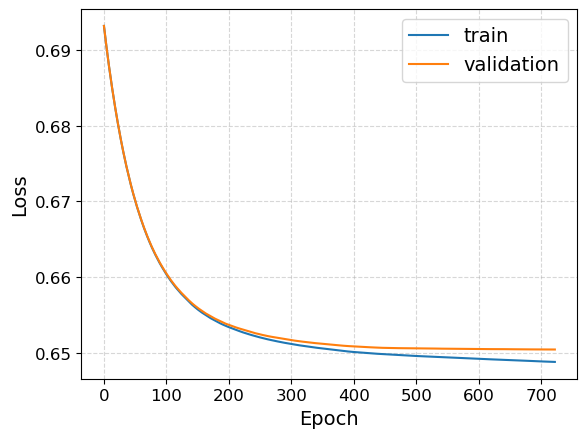

In [14]:
train_loss = [-s for s in clf.train_score_]
val_loss   = [-s for s in clf.validation_score_]

def set_plot_style():
	plt.rcParams.update({
		"font.size": 12,
		"axes.labelsize": 14,
		"xtick.labelsize": 12,
		"ytick.labelsize": 12,
		"legend.fontsize": 14,
		"lines.linewidth": 1.5
	})
	
set_plot_style()

plt.plot(train_loss, label="train")
plt.plot(val_loss, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.5, linestyle='--')
plt.legend()
plt.show()


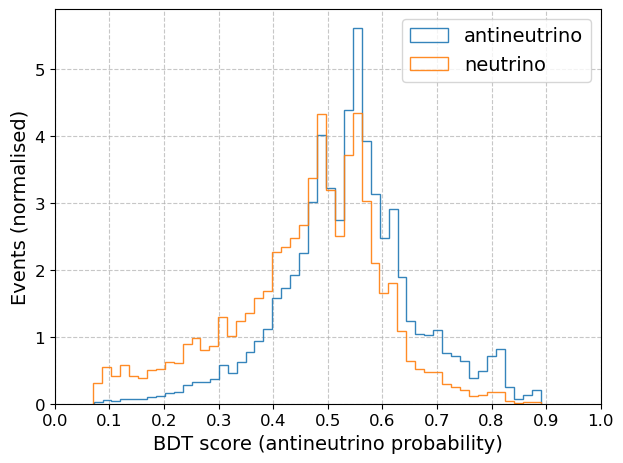

[0.48165146 0.54604917 0.40035378 ... 0.43464251 0.6132428  0.74020562]


In [15]:


score = clf.predict_proba(X_test)[:,1]


plt.hist(score[y_test==1], bins=50, alpha=0.9, label="antineutrino", density = True,  histtype="step")
plt.hist(score[y_test==0], bins=50, alpha=0.9, label="neutrino", density = True, histtype="step")

plt.xlabel("BDT score (antineutrino probability)")
plt.xticks(np.arange(0, 1.1, 0.1))
plt.ylabel("Events (normalised)")
plt.legend()
plt.tight_layout()
plt.grid(linestyle="--", alpha=0.7)
plt.savefig("bdt_score_histogram.pdf")
plt.show()

print(score)

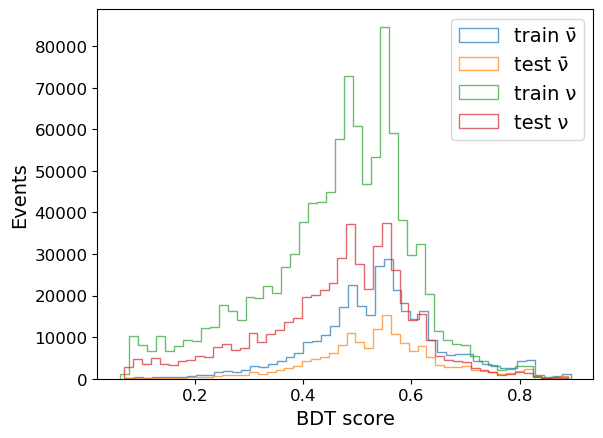

In [16]:
score_train = clf.predict_proba(X_train)[:,1]
score_test  = clf.predict_proba(X_test)[:,1]

plt.hist(score_train[y_train==1], bins=50, alpha=0.7, label="train ν̄",histtype = 'step')
plt.hist(score_test[y_test==1],  bins=50, alpha=0.7, label="test ν̄", histtype = 'step')

plt.hist(score_train[y_train==0], bins=50, alpha=0.7, label="train ν", histtype = 'step')
plt.hist(score_test[y_test==0],  bins=50, alpha=0.7, label="test ν", histtype = 'step')

plt.xlabel("BDT score")
plt.ylabel("Events")
plt.legend()
plt.show()



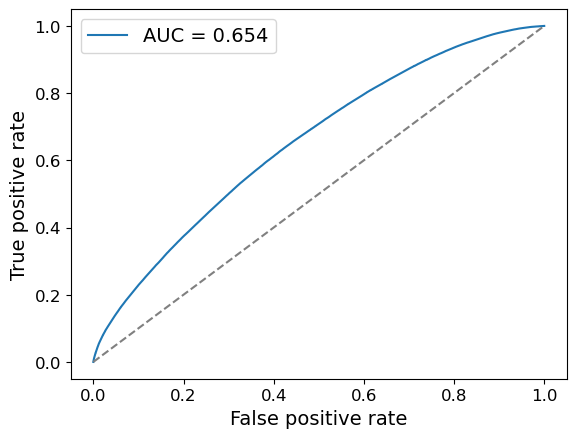

In [17]:
from sklearn.metrics import roc_curve, auc

probs = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.savefig("roc_curve.pdf")
plt.show()


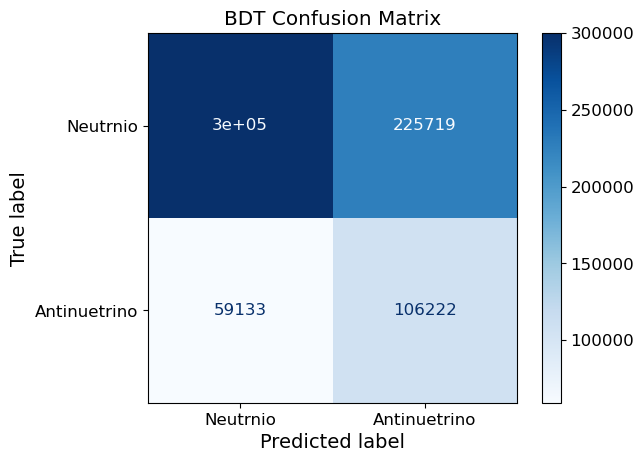

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutrnio', 'Antinuetrino'])
disp.plot(cmap=plt.cm.Blues)
plt.title("BDT Confusion Matrix")
plt.show()

In [19]:
from sklearn.inspection import permutation_importance
r = permutation_importance(clf, X_data, y_data, n_repeats=5)


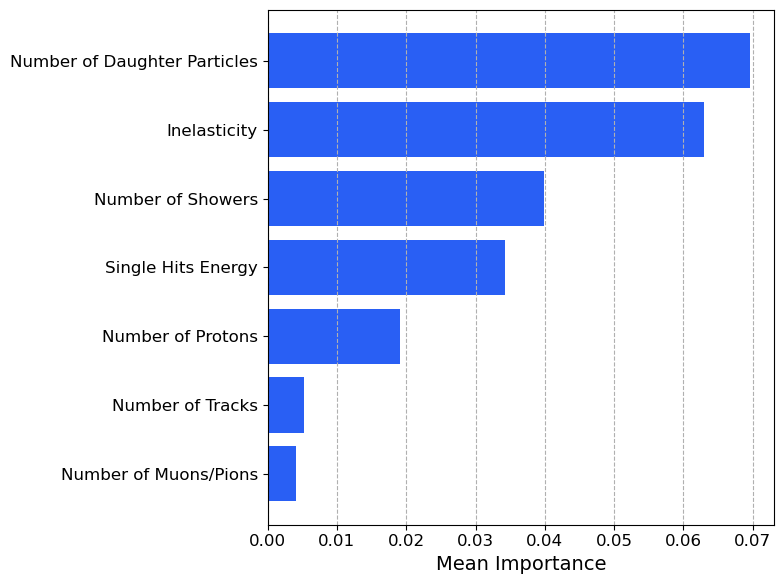

In [20]:
label_map = {
    "Enu_e_had": "Hadronic Energy (e)",
    "Enu_e_calo": "Calorimetric Energy (e)",
    "Enu_mu_had": "Hadronic Energy (μ)",
    "Enu_mu_range": "Range-based Energy (μ)",
    "PDG": "True PDG Code",
    "n_reco_pfps": "Number of Daughter Particles",
    "n_reco_tracks": "Number of Tracks",
    "n_reco_showers": "Number of Showers",
    "n_reco_muons_pions": "Number of Muons/Pions",
    "n_reco_protons": "Number of Protons",
    "single_hits_energy": "Single Hits Energy",
    "n_true_nu": "N True Neutrinos",
    "n_primary_daughters": "N Primary Daughters",
    "n_primary_electrons": "N Primary Electrons",
    "n_primary_muons": "N Primary Muons",
    "n_primary_protons": "N Primary Protons",
    "n_primary_pions": "N Primary Pions",
    "n_primary_photons": "N Primary Photons",
    "n_primary_pi0s": "N Primary π⁰s",
    "n_primary_tracks": "N Primary Tracks",
    "n_primary_showers": "N Primary Showers",
    "inelasticity_e": "Inelasticity (e)",
    "inelasticity_mu": "Inelasticity (μ)",
    "inelasticity": "Inelasticity",
}


means = r["importances_mean"]
sorted_idx = np.argsort(means)

plt.figure(figsize=(8, 6))
plt.grid(axis="x", linestyle="--", alpha=1)
plt.barh(
    [label_map.get(feature_columns[i], feature_columns[i]) for i in sorted_idx],
    means[sorted_idx], color = "#295FF4"
)
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.savefig("feature_importance.pdf", dpi = 300)
plt.show()

In [21]:
print(np.argsort(means), means[sorted_idx])



[5 2 6 4 3 0 1] [0.00402943 0.00523697 0.01905919 0.03422617 0.03985783 0.06297491
 0.06959265]


In [22]:
from sklearn.metrics import log_loss

x = log_loss(y_true=y_test, y_pred=probs)
print(x)

0.6514623838477954


In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Neutrino', 'Antineutrino']))

              precision    recall  f1-score   support

    Neutrino       0.84      0.57      0.68    525777
Antineutrino       0.32      0.64      0.43    165355

    accuracy                           0.59    691132
   macro avg       0.58      0.61      0.55    691132
weighted avg       0.71      0.59      0.62    691132



691132
2094339
691131.87


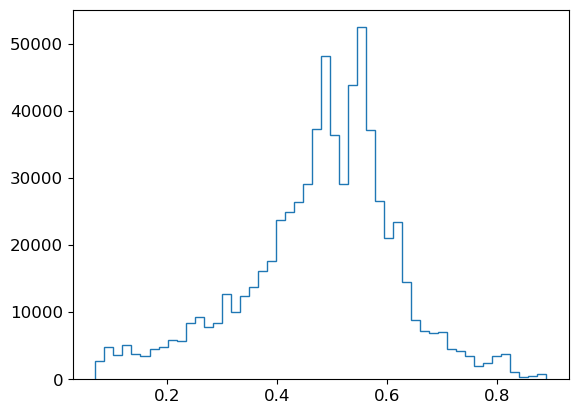

In [24]:
plt.hist(score, histtype="step", bins=50, label="test" )
print(len(score))
print(len(y_data))
print(0.33*len(y_data))

In [25]:
hard_predictions = clf.predict(X_data)
probs = clf.predict_proba(X_data)
decision_scores = clf.decision_function(X_data)


results_df = pd.DataFrame({
    'true_label': y_data,
    'predicted_label': hard_predictions,
    'prob_neutrino': probs[:, 0],
    'prob_antineutrino': probs[:, 1],
    'decision_score': decision_scores
})



print(results_df.head())

   true_label  predicted_label  prob_neutrino  prob_antineutrino  \
0           1                1       0.431291           0.568709   
1           1                1       0.442298           0.557702   
2           1                0       0.584096           0.415904   
3           0                0       0.909404           0.090596   
4           1                1       0.448327           0.551673   

   decision_score  
0        0.276587  
1        0.231840  
2       -0.339611  
3       -2.306383  
4        0.207434  


In [26]:
score_column = results_df['prob_antineutrino']

In [27]:
all_probs = clf.predict_proba(X_data)[:, 1]

final_output = pd.DataFrame({
    'event_index': data['event_index'],
    'bdt_score': all_probs
})

final_output.to_csv("bdt_scores_with_index_revised_and_cut_inelastcity.csv", index=False)

In [28]:
final_output

,event_index,bdt_score
0,0,0.568709
1,1,0.557702
2,2,0.415904
3,4,0.090596
6,7,0.551673
...,...,...
2651020,2884696,0.494507
2651021,2884697,0.386699
2651023,2884699,0.481172
2651024,2884700,0.452531


In [31]:
fpr, tpr, thresholds = roc_curve(y_data, all_probs)
j_scores = tpr - fpr
best_threshold = thresholds[np.argmax(j_scores)]
# find threshold where TPR ≈ TNR 
# best_threshold = thresholds[np.argmin(np.abs(tpr - (1 - fpr)))]
print(best_threshold)

0.49619164178942604


In [30]:
# all_probs = clf.predict_proba(X_data)[:, 1]


# final_output = pd.DataFrame({
#     'event_index': data['event_index'],
#     'bdt_score': np.random.uniform(0, 1, len(all_probs))
# })


# final_output.to_csv("randomised_bdt_scores_with_index.csv", index=False)